<a href="https://colab.research.google.com/github/mjh5153/comply-api-blueprint/blob/main/AppliedMachineLearning_UnsupervisedLearning_May9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

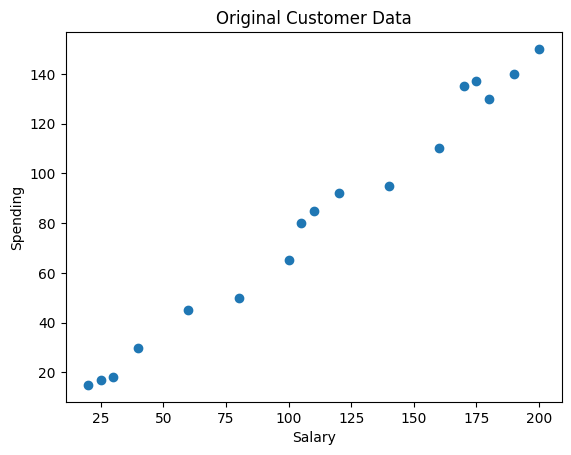

In [20]:
# Supervised - machine learns from the data

# 1. Machine given label; apple, orange, banana
# 2. Model learns from labels

# B. Unsupervised example -
# 1. Clustering - animals ( eda - null values to be removed)
# a. Grouping similar data together - customer segmentation - grocery store customer types: segment customer age:products:prices
# b. Student performance group : k-means, hierarchical clustering
# c. Disease Grouping
                          # predict risk group and then treatment plan, supervised in prediction- die or survive
# age, disease, severity, die

# feed data, analyze data, find similar pattern = clustering ( similar patients grouped together)

#C. association - find relationship between items - create cluster ( butter, bread -- $$ probability )
# k mean clustering - machine creates k mean groups
#   clstr1, clstr2, ?? need 3 clusters
#   centroid
#   pick random points
# k = 2
# best k ?
# model - checks distece of these with all the data points (clusters : points ? nearpoint ? makecolorofpoint)
# 2 clusters created from data in 3 different data types - k = 2 ( not correct because data points far away from center (d1 +d2, etc.. high from center ( model creates )))
# model - Creates center
# model - finds minimal distance
# Elbow method -> best clusters to use
# y:wcss( (d1 + d2) + (y1+y2 ), x1+x2), x:cltstrs --- as k increases centroid descreases vertically --- k value depends on result of elbow method ( like an elbow ) at elbow on plotted graph = Best K or turning point

# hierachical - step by step like family tree

# Dendogram graph

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
# wcss = sum of squares
# wcss = distance from centroid ( average)
# generate dynamically - job loss of ML people because they aren't utilizing AI
data = {
    'Salary': [20, 25, 30, 40, 60, 80, 100, 105, 110, 120, 140, 160, 180, 170, 175, 190, 200],
    'Spending': [15, 17, 18, 30, 45, 50, 65,  80,  85, 92, 95,  110, 130, 135, 137, 140, 150]
}

# Create DataFrame
df = pd.DataFrame(data)


# visualize original data
plt.scatter(df['Salary'], df['Spending'])

plt.title("Original Customer Data")
plt.xlabel("Salary");
plt.ylabel("Spending")

plt.show()

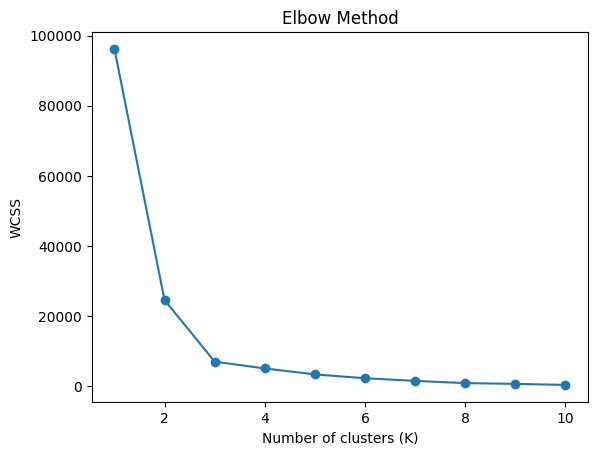

In [21]:
# elbow method

wcss = []

for i in range(1,11):
    model = KMeans(n_clusters=i,
                   random_state=42) # any number, anchor model, not required
    model.fit(df)
    wcss.append(model.inertia_)
wcss
# k - 1: value, 2 : value, etc.. find optimal graph
plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Method")
plt.xlabel("Number of clusters (K)")
plt.ylabel("WCSS")

plt.show()

# Elbow at K=3

    Salary  Spending  Cluster
0       20        15        2
1       25        17        2
2       30        18        2
3       40        30        2
4       60        45        2
5       80        50        0
6      100        65        0
7      105        80        0
8      110        85        0
9      120        92        0
10     140        95        0
11     160       110        1
12     180       130        1
13     170       135        1
14     175       137        1
15     190       140        1
16     200       150        1


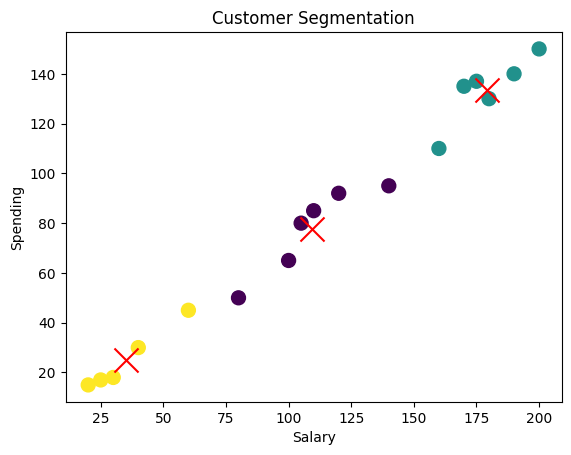

In [22]:
# Step 6. Observations and plot

# Trained mode - model divided to 3 clusters -

model  = KMeans(n_clusters=3,random_state=42)

model.fit(df)

# Step 7 - Apply final k means



# 8 Create new column
df['Cluster'] = model.predict(df)

print(df)



#9: Final Visualization - scatter plot - elbow chart defines

plt.scatter(df['Salary'], df['Spending'], c=df['Cluster'], s=100)

plt.scatter(model.cluster_centers_[:,0],
            model.cluster_centers_[:,1],
            marker='x',
            s=300,
            color='red')

plt.title("Customer Segmentation") # x is centroid value
plt.xlabel("Salary")
plt.ylabel("Spending")

plt.show()

In [26]:
# Real-Time Applications

# prediction

new_customer = [[66, 62]]

# cluster 2, 0, 1 ? mid range ( cluster 0

prediction = model.predict(new_customer)

print("predicted cluster:", prediction)

# confidence for particular model?

# Confidence identification : example 92%
# But no trainx testx data only have input which used to create clusters

## Knowing cluster for predictions

## Large grouping ? Customer Segmentation

## Train model to create clusters

# 1. Silhoutte Score - value close 2 1 ? model is good ( cllustering good ) How close points are that inside the cluster AND how far clusters are from each other
# 2. Davis Boulding Index ( CDBI ) - Create DBI Score - How compact the clusters are?
## less DB1 ? better model

from sklearn.metrics import silhouette_score
score = silhouette_score(df[['Salary', 'Spending']], df['Cluster']

                         )

print("silhouette score is : ", score)


# DBI

from sklearn.metrics import davies_bouldin_score
dbi_score = davies_bouldin_score(df[['Salary', 'Spending']], df['Cluster']

                         )

print("dbi score is : ", dbi_score)

# when db low and silhouette high - good working model
# Data points can cause clusters to be farther apart

# AI auto checks silhouette score which is used primarily in industry
# If outliers, should be remove from dataset


predicted cluster: [0]
silhouette score is :  0.6306041115284742
dbi score is :  0.39241672266378974


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


In [ ]:
# Association Rule Learning - Unsupervised technique
# hidden relationships between items in data

# What is it? Why do I care, Where does it apply?

# terms: 1. Support -> How frequently items appear togehter ( (A -> B)) = Transaction containing A&b / total transactions
## 5 transaction - 3 with bread and butter -  equation = 3/5

    # 2. Confidence -> Often B purchased when A is purchased = transactions containing A& B/ transaction containing A
    # Example: 3/4


    # 3. Lift -> Stength of relationship is ( Bread and Butter - two data points and products ) Confidence(A-> B/Support ( B) = 3/4 / 3/5 = 5/4 ( > 1 ? strong , = 1 -> no relation, < 1 ? negative relationship )

# Types of Algorithms - 1. Apriori - find frequesnt item sets [ Mainly used in Professional ],
# 2. Clat,
# 3. fpgrowth - efficient for large data

# Step 1 - find frequent purcheased single items : i.e. milk, bread, butter purchased most
# Step 2 - find frequent pairs :
# Step 3 - Generate Rule ( next class )

